
Dataset Preview:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dataset Shape: (303, 14)


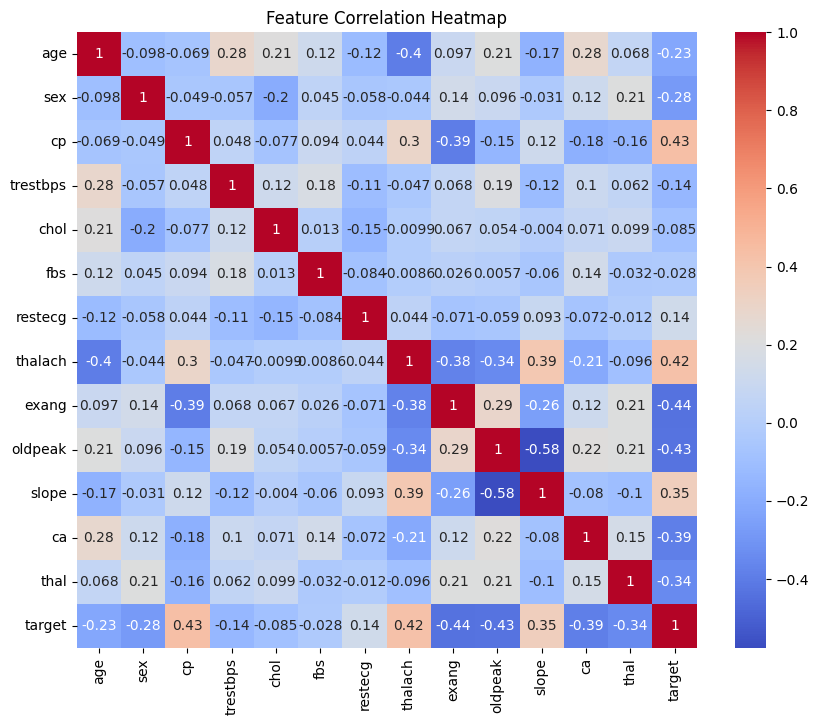

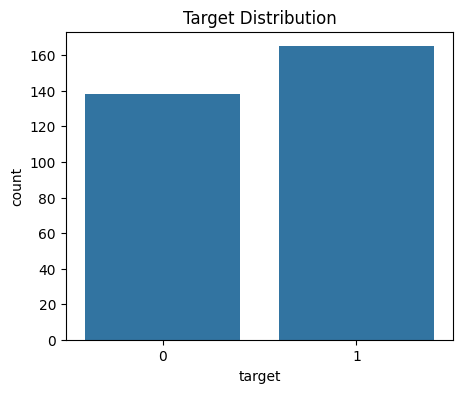


Explained Variance Ratio: [0.21393021 0.12763724]

Training Model: Linear Kernel
Accuracy: 0.8351648351648352

Confusion Matrix:
[[33  8]
 [ 7 43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        41
           1       0.84      0.86      0.85        50

    accuracy                           0.84        91
   macro avg       0.83      0.83      0.83        91
weighted avg       0.83      0.84      0.83        91


Training Model: Polynomial Kernel
Accuracy: 0.8021978021978022

Confusion Matrix:
[[29 12]
 [ 6 44]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.71      0.76        41
           1       0.79      0.88      0.83        50

    accuracy                           0.80        91
   macro avg       0.81      0.79      0.80        91
weighted avg       0.81      0.80      0.80        91


Training Model: RBF Kernel
Accuracy: 0.8351648

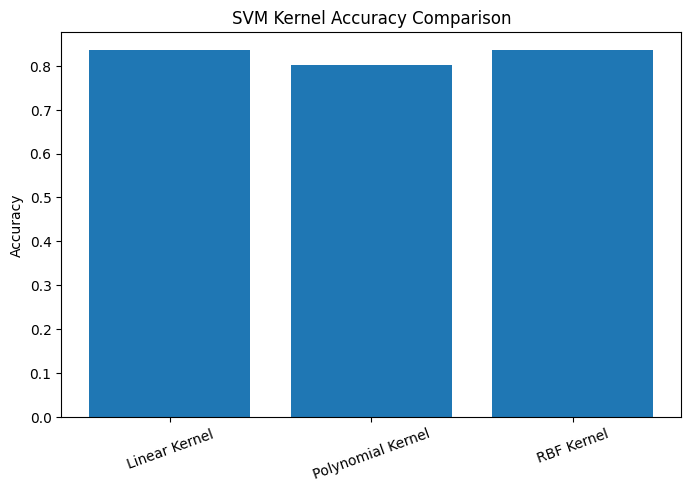

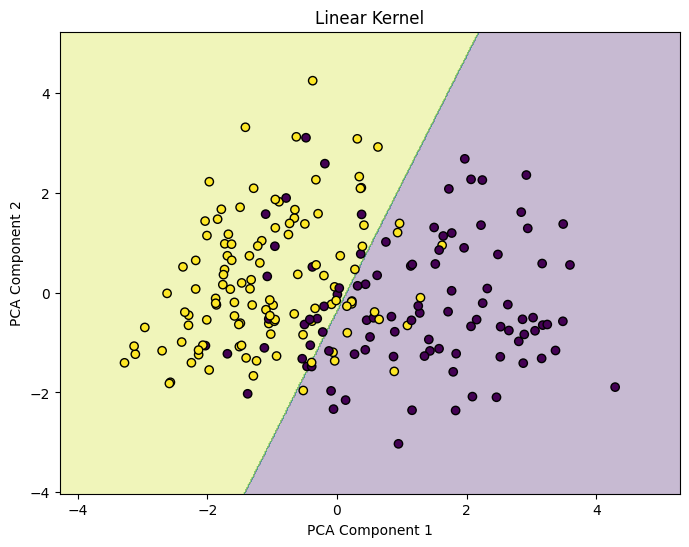

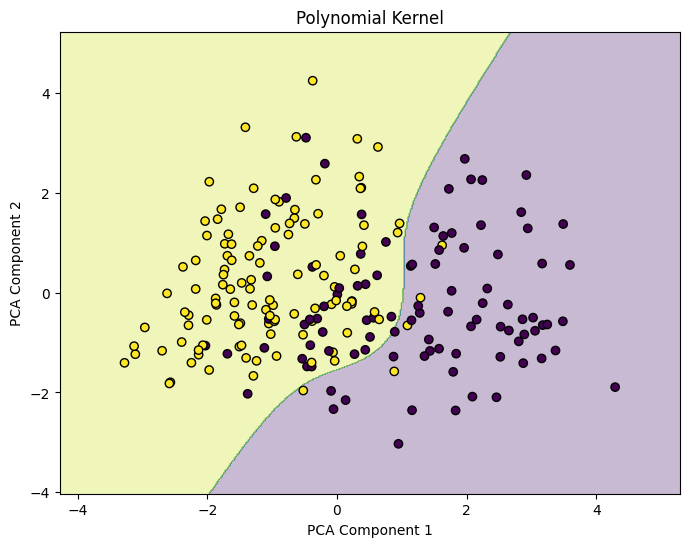

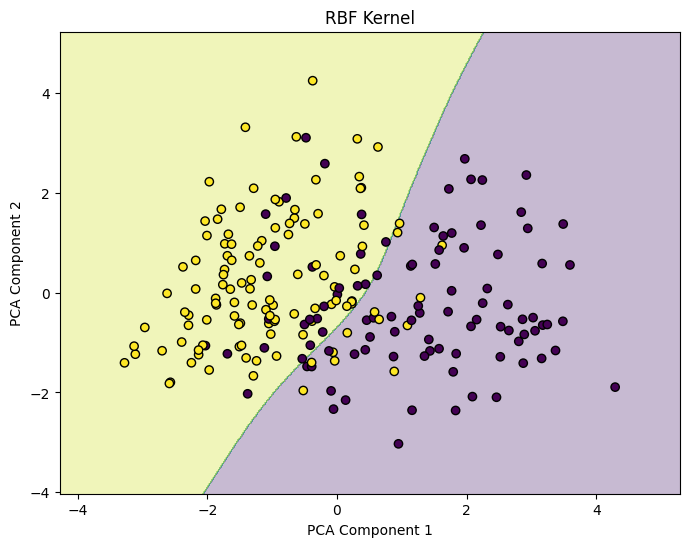

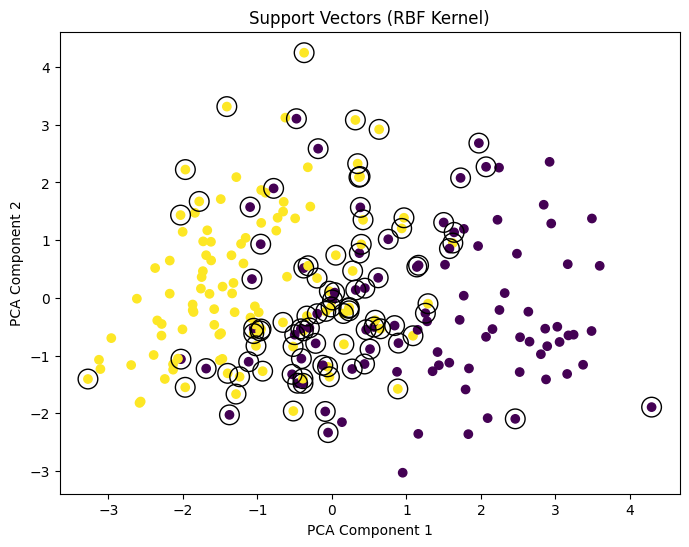


================ FINAL SUMMARY ================
Linear Kernel: 0.8352
Polynomial Kernel: 0.8022
RBF Kernel: 0.8352

Best Performing Kernel: Linear Kernel


In [3]:
# ============================================================
# ONE-FILE ML PROJECT: SVM Kernel Comparison
# Topic: Effect of Kernel Functions on Classification Performance
# Dataset: Heart Disease Dataset
# ============================================================

# ===============================
# 0. Import Libraries
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ===============================
# 1. Load Dataset
# ===============================

df = pd.read_csv("/content/sample_data/heart.csv")

print("\nDataset Preview:")
print(df.head())

print("\nDataset Shape:", df.shape)

X = df.drop("target", axis=1)
y = df["target"]

# ===============================
# 2. Exploratory Data Analysis
# ===============================

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()

# ===============================
# 3. Train-Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ===============================
# 4. Feature Scaling
# ===============================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 5. PCA for Visualization
# ===============================

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nExplained Variance Ratio:", pca.explained_variance_ratio_)

# ===============================
# 6. Train SVM Models (Kernel Comparison)
# ===============================

models = {
    "Linear Kernel": SVC(kernel='linear'),
    "Polynomial Kernel": SVC(kernel='poly', degree=3),
    "RBF Kernel": SVC(kernel='rbf')
}

results = {}

for name, model in models.items():

    print("\n====================================")
    print(f"Training Model: {name}")
    print("====================================")

    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", acc)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# ===============================
# 7. Accuracy Comparison Plot
# ===============================

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("SVM Kernel Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

# ===============================
# 8. Decision Boundary Visualization
# ===============================

def plot_decision_boundary(model, X, y, title):

    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

# ===============================
# 9. Plot Decision Boundaries
# ===============================

for name, model in models.items():
    plot_decision_boundary(model, X_train_pca, y_train, name)

# ===============================
# 10. Support Vectors Visualization (RBF)
# ===============================

rbf_model = models["RBF Kernel"]

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train)

plt.scatter(rbf_model.support_vectors_[:,0],
            rbf_model.support_vectors_[:,1],
            s=200, facecolors='none', edgecolors='k')

plt.title("Support Vectors (RBF Kernel)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# ===============================
# 11. Summary
# ===============================

print("\n================ FINAL SUMMARY ================")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

best_model = max(results, key=results.get)
print(f"\nBest Performing Kernel: {best_model}")